   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
<class '

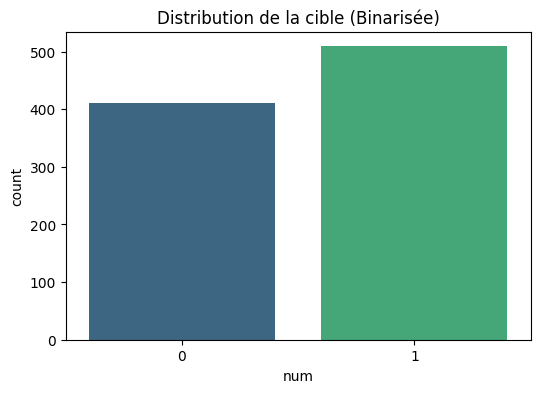

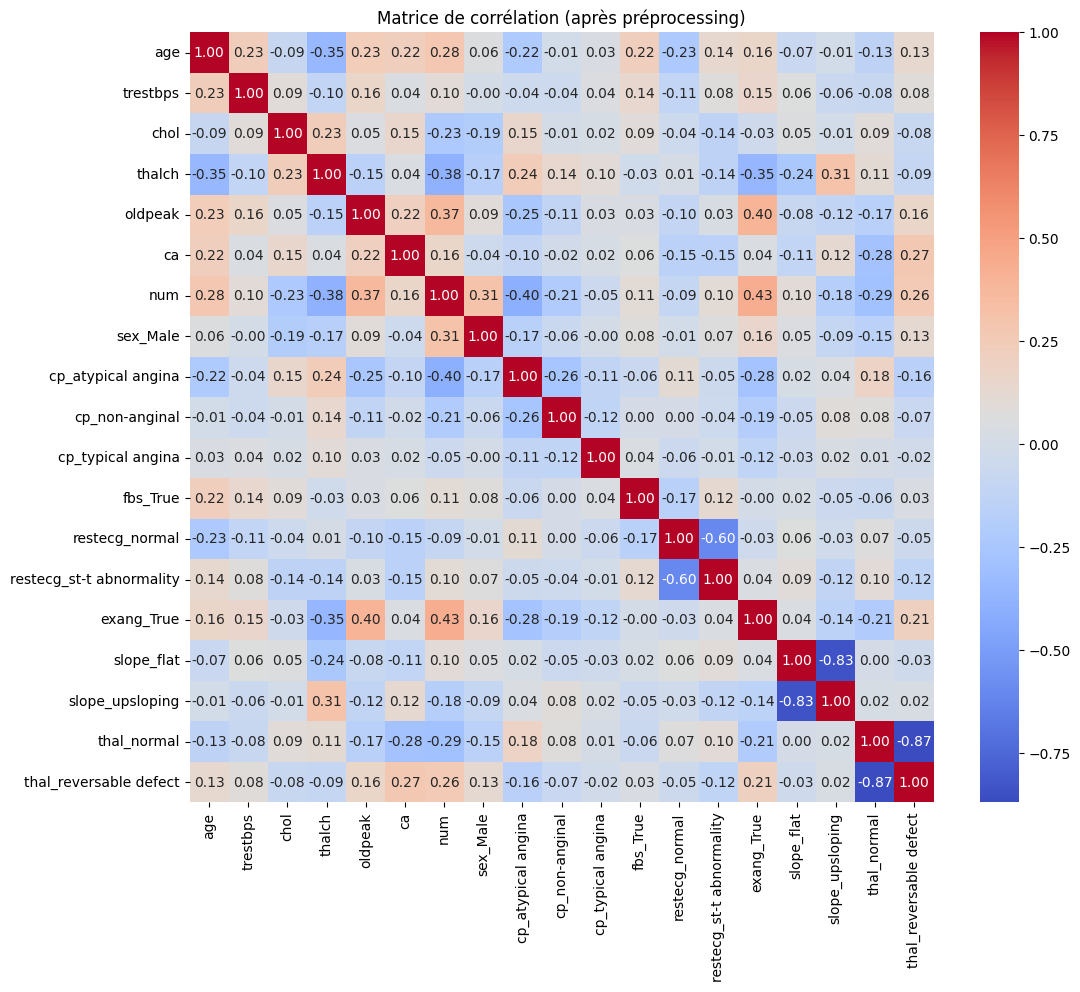


Accuracy : 0.8424

Rapport de classification :
                precision    recall  f1-score   support

Pas de maladie       0.84      0.79      0.82        82
       Maladie       0.84      0.88      0.86       102

      accuracy                           0.84       184
     macro avg       0.84      0.84      0.84       184
  weighted avg       0.84      0.84      0.84       184



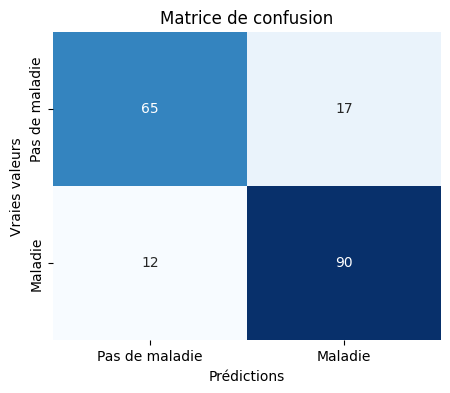

In [21]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Chargement du dataset
df = pd.read_csv('heart_disease_uci.csv')

# Aperçu des données
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# --- Prétraitement des données ---
# Copie pour ne pas modifier le DataFrame original
df_processed = df.copy()

# Suppression des colonnes 'id' (identifiant) et 'dataset' (source, non utile ici)
df_processed = df_processed.drop(['id', 'dataset'], axis=1)

# Identification des colonnes numériques et catégorielles
numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'num']  # on exclut la cible
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

# Imputation des valeurs manquantes pour les colonnes numériques (par la médiane)
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)

# Imputation des valeurs manquantes pour les colonnes catégorielles (par le mode)
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)

# Encodage one-hot des variables catégorielles
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True, dtype=int)

# Transformation de la cible multi-classe (num : 0,1,2,3,4) en binaire (0 = pas de maladie, 1 = maladie)
df_processed['num'] = df_processed['num'].apply(lambda x: 1 if x > 0 else 0)

# Visualisation de la distribution de la cible après binarisation
plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df_processed, palette='viridis')
plt.title('Distribution de la cible (Binarisée)')
plt.show()

# Matrice de corrélation après prétraitement
plt.figure(figsize=(12,10))
sns.heatmap(df_processed.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation (après préprocessing)')
plt.show()

# Séparation des features (X) et de la cible (y)
X = df_processed.drop('num', axis=1)
y = df_processed['num']

# Division en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardisation des features (moyenne=0, écart-type=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle de régression logistique
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test_scaled)

# Évaluation du modèle : accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy:.4f}\n")

# Rapport de classification (précision, rappel, f1-score)
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Pas de maladie', 'Maladie']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pas de maladie', 'Maladie'],
            yticklabels=['Pas de maladie', 'Maladie'])
plt.xlabel('Prédictions')
plt.ylabel('Vraies valeurs')
plt.title('Matrice de confusion')
plt.show()